In [20]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras

The Allen-Cahn equation is
$$\frac{\partial u}{\partial t} = M \left[ \div(\epsilon^2 \nabla u - f'(u)) \right]$$

For certain choices of $M$ and $\epsilon$ in 1 spatial dimension, we get the PDE:
$$\frac{\partial u}{\partial t} - 0.0001\frac{\partial^2 u}{\partial x^2} + 5u^3 - 5u = 0$$

Let us choose the initial and boundary conditions, and diffusion coefficient $\nu$:
$$u(0,x) = x^2\cos(\pi x)$$
$$u(t,-1) = u(t,1)$$
$$u_x(t,-1) = u_x(t,1)$$

We'll evolve $u(0,x)$ using Runge-Kutta methods. Let's define $u^{n+c_j}=u(t^n+c_j\Delta t, x)$. Applying an RK method with $q$ stages on the PDE, we get
$$u^{n+1} = u^n - \Delta t \sum_{j=1}^q b_j\left(u^{n+c_j}u_x^{n+c_j}-\nu u_{xx}^{n+c_j}\right)$$
where
$$u^{n+c_i} = u^n - \Delta t \sum_{j=1}^q a_{ij}\left(u^{n+c_j}u_x^{n+c_j}-\nu u_{xx}^{n+c_j}\right)\ \mathrm{where}\ i\in\{1,...,q\}$$

We build a $(q+1)$-out dense neural network that, at time $t^n$, does
$$x \mapsto \left[u^{n+c_1}(x),...,u^{n+c_q}(x),u^{n+1}(x)\right] \mapsto \left[u_1^n(x),...,u_q^n(x),u_{q+1}^n(x)\right]$$

The loss functions are
$$L_n = \sum_{j=1}^{q+1} \sum_{i=1}^{N_n} |u_j^n(x^{n,i}) - u^{n,i}|^2$$
$$L_b = \sum_{i=1}^q\left(|u^{n+c_i}(-1)|^2+|u^{n+c_i}(1)|^2\right) + |u^{n+1}(-1)|^2 + |u^{n+1}(1)|^2$$
$$L_\mathrm{total} = L_n + \phi L_b$$
where $\phi$ modulates the relative importance of boundary conditions.

Note: Since the NN takes as input a 0d tensor $x$ to compute a 1d tensor $u^{n+c_j}$, we can input a 1d tensor $x$ to compute a 2d tensor $u^{n+c_j}$ akin to batching. Every iteration, we also have to compute the 2d tensors $u_x^{n+c_j}$ and $u_{xx}^{n+c_j}$ to calculate the loss. So we have to choose the nested `tf.GradientTape` method carefully.
- `gradient` only outputs a 1d tensor, so we have to loop it over each row, for each nest. Too slow.
- `jacobian` outputs a 3d tensor, so we have to `einsum` the output, for each nest. Too memory-intensive.
- `batch_jacobian` outputs a 2d tensor (with an extra dimension that can be squeezed out). Too many retraces, too memory-intensive, too slow.
- `batch_jacobian` with `tf.vectorized_map`. Haven't tried this yet.

`tf.autodiff.ForwardAccumulator` uses forward-mode autodiff as opposed to all the above methods that use reverse-mode autodiff (backprop). Since the input size per batch is just 1, one forward pass gives all derivatives at once. Fast, memory-efficient.

In [21]:
def get_RK_Abc(q):
    tmp = np.float32(np.loadtxt('../data/Butcher_IRK%d.txt' % (q), ndmin = 2))
    IRK_weights = np.reshape(tmp[0:q**2+q], (q+1,q))
    IRK_times = tmp[q**2+q:]
    del tmp
    Ab = tf.convert_to_tensor(IRK_weights, dtype=tf.float32)
    c = tf.convert_to_tensor(IRK_times, dtype=tf.float32)
    return Ab, c

In [22]:
class NeuralNetwork:
    def __init__(self, width, depth) -> None:
        self.f_factor = 1.  # relative importance of boundary conditions
        self.N_n = 200
        self.x = tf.convert_to_tensor(np.linspace(-1, 1, self.N_n), dtype=tf.float32)[:,None]  # (N_n, 1)
        self.u0 = self.u_at_t0(self.x)
        self.dt = 0.8  # time step
        self.q = 100  # RK stages
        self.model = self.get_model(width, depth)
        self.Ab, self.c = get_RK_Abc(self.q)
    
    def get_model(self, width, depth):
        model = keras.models.Sequential()
        model.add(keras.layers.InputLayer(shape=(1,)))
        for _ in range(depth):
            model.add(keras.layers.Dense(width, activation='tanh'))
        model.add(keras.layers.Dense(self.q+1, activation=None))
        return model
    
    def u_n_c(self, x):  # (N_n, q+1)
        return self.model(x)
    
    def u_ux_uxx(self, x):
        with tf.autodiff.ForwardAccumulator(
            primals=x,
            tangents=tf.ones_like(x),
        ) as acc_outer:
            with tf.autodiff.ForwardAccumulator(
                primals=x,
                tangents=tf.ones_like(x),
            ) as acc_inner:
                u = self.u_n_c(x)
            u_x = acc_inner.jvp(u)
        u_xx = acc_outer.jvp(u_x)
        return u, u_x, u_xx
    
    def N(self, x):
        # non-linear operator
        u, u_x, u_xx = self.u_ux_uxx(x)
        non_lin = -0.0001 * u_xx + 5 * u**3 - 5 * u
        return u, u_x, non_lin

    def u_n_i(self, x):
        u_n_c, u_x, non_lin = self.N(x)
        u_n_i = u_n_c + self.dt * tf.matmul(non_lin[:,:-1], self.Ab, transpose_b=True)
        return u_n_c, u_x, u_n_i
    
    def u_at_t0(self, x):
        u = x**2 * np.cos(np.pi * x).astype(np.float32)
        return tf.convert_to_tensor(u, dtype=tf.float32)

    def get_loss(self, x):
        # TODO: u0 at any t_n, not just t_0
        u_n_c, u_x, u_n_i = self.u_n_i(x)
        # sum dimension order doesn't matter
        loss_n = tf.reduce_sum(tf.square(u_n_i - self.u0))

        loss_b = tf.reduce_sum(tf.square(u_n_c[0] - u_n_c[-1])) + tf.reduce_sum(tf.square(u_x[0] - u_x[-1]))

        loss = loss_n + self.f_factor * loss_b
        return loss, loss_n, loss_b

    @tf.function
    def train_step(self, optimizer):
        with tf.GradientTape() as tape:
            loss, loss_n, loss_b = self.get_loss(self.x)
        grads = tape.gradient(loss, self.model.trainable_variables)
        optimizer.apply_gradients(zip(grads, self.model.trainable_variables))
        return loss, loss_n, loss_b
    
    def show_state(self, title=''):
        n_t = 64 + 1
        n_x = 128
        u_n_c, _, u_n_i = self.u_n_i(self.x)
        fig, axes = plt.subplots(2, 1, figsize=(20, 8), layout='tight')
        for ax, u in zip(axes, [u_n_c, u_n_i]):
            im = ax.imshow(u, origin='lower', aspect='auto', interpolation='none', extent=(0, 1, -1, 1), cmap='viridis')
            ax.axhline(0, c='k', ls='--')
            plt.colorbar(im)
            ax.set_ylabel('x')
        axes[0].set_xlabel('time')
        axes[1].set_xlabel('stage')
        axes[0].set_title(title)
        return fig, ax

In [23]:
neural_network = NeuralNetwork(width=200, depth=3)
_ = neural_network.model(neural_network.x)

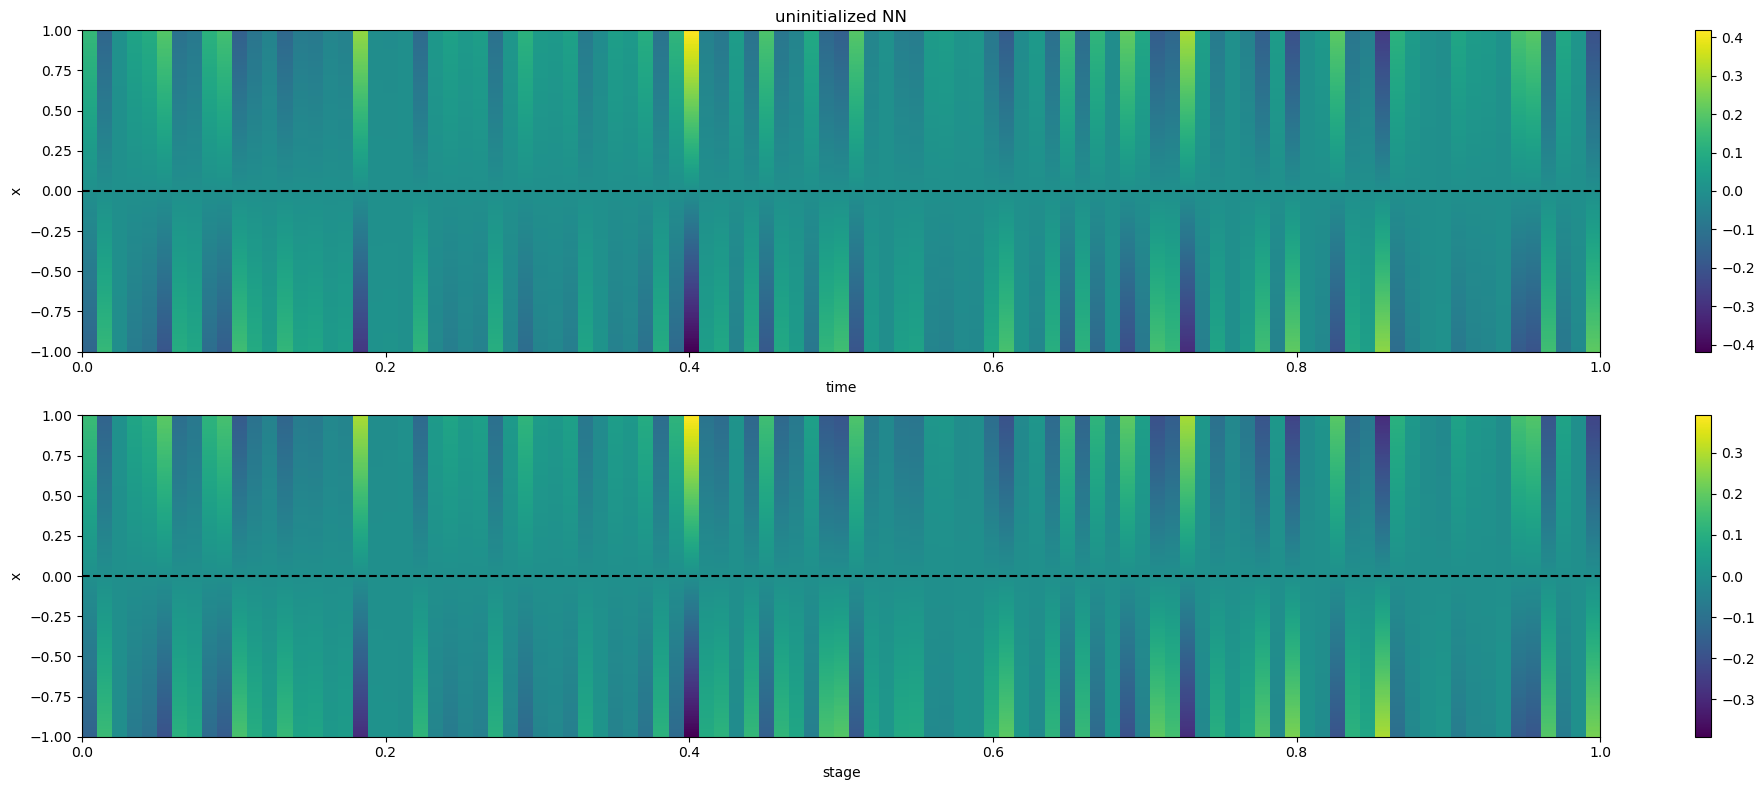

In [24]:
neural_network.show_state("uninitialized NN");

In [25]:
# optimizer = keras.optimizers.SGD(learning_rate=0.02)
optimizer = keras.optimizers.Adam(learning_rate=1e-3)
neural_network.model.compile(optimizer)

In [26]:
EPOCHS = 10_000
history = {"loss": [], "loss_n": [], "loss_b": []}
for epoch in range(1, EPOCHS + 1):
    loss, loss_n, loss_b = neural_network.train_step(optimizer)
    history["loss"].append(float(loss))
    history["loss_n"].append(float(loss_n))
    history["loss_b"].append(float(loss_b))
    if epoch % 500 == 0 or epoch == 1:
        print(f"epoch {epoch:5d} | loss {loss:.4e} | loss_n {loss_n:.2e} | loss_b {loss_b:.2e}")
    if epoch % 2000 == 0:
        new_LR = optimizer.learning_rate.numpy() / 2
        optimizer.learning_rate.assign(new_LR)

epoch     1 | loss 3.0818e+03 | loss_n 3.08e+03 | loss_b 5.77e+00
epoch   500 | loss 1.1707e+03 | loss_n 1.12e+03 | loss_b 5.12e+01
epoch  1000 | loss 2.0009e+02 | loss_n 1.90e+02 | loss_b 1.05e+01
epoch  1500 | loss 1.2795e+02 | loss_n 1.21e+02 | loss_b 7.00e+00
epoch  2000 | loss 6.6529e+01 | loss_n 6.23e+01 | loss_b 4.27e+00
epoch  2500 | loss 5.0744e+01 | loss_n 4.81e+01 | loss_b 2.64e+00
epoch  3000 | loss 4.1114e+01 | loss_n 3.96e+01 | loss_b 1.48e+00
epoch  3500 | loss 3.4970e+01 | loss_n 3.40e+01 | loss_b 9.61e-01
epoch  4000 | loss 4.1917e+01 | loss_n 4.08e+01 | loss_b 1.14e+00
epoch  4500 | loss 2.8420e+01 | loss_n 2.78e+01 | loss_b 6.68e-01
epoch  5000 | loss 2.5987e+01 | loss_n 2.54e+01 | loss_b 6.19e-01
epoch  5500 | loss 2.3449e+01 | loss_n 2.29e+01 | loss_b 5.68e-01
epoch  6000 | loss 2.1750e+01 | loss_n 2.11e+01 | loss_b 6.02e-01
epoch  6500 | loss 2.0353e+01 | loss_n 1.99e+01 | loss_b 4.64e-01
epoch  7000 | loss 1.9252e+01 | loss_n 1.88e+01 | loss_b 4.15e-01
epoch  750

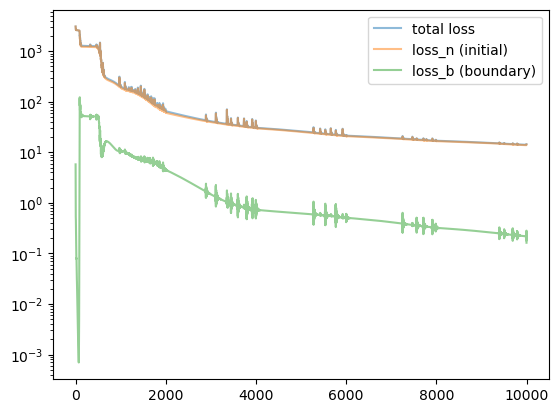

In [27]:
plt.yscale('log')
plt.plot(history['loss'], alpha=0.5, label='total loss')
plt.plot(history['loss_n'], alpha=0.5, label='loss_n (initial)')
plt.plot(history['loss_b'], alpha=0.5, label='loss_b (boundary)')
plt.legend();

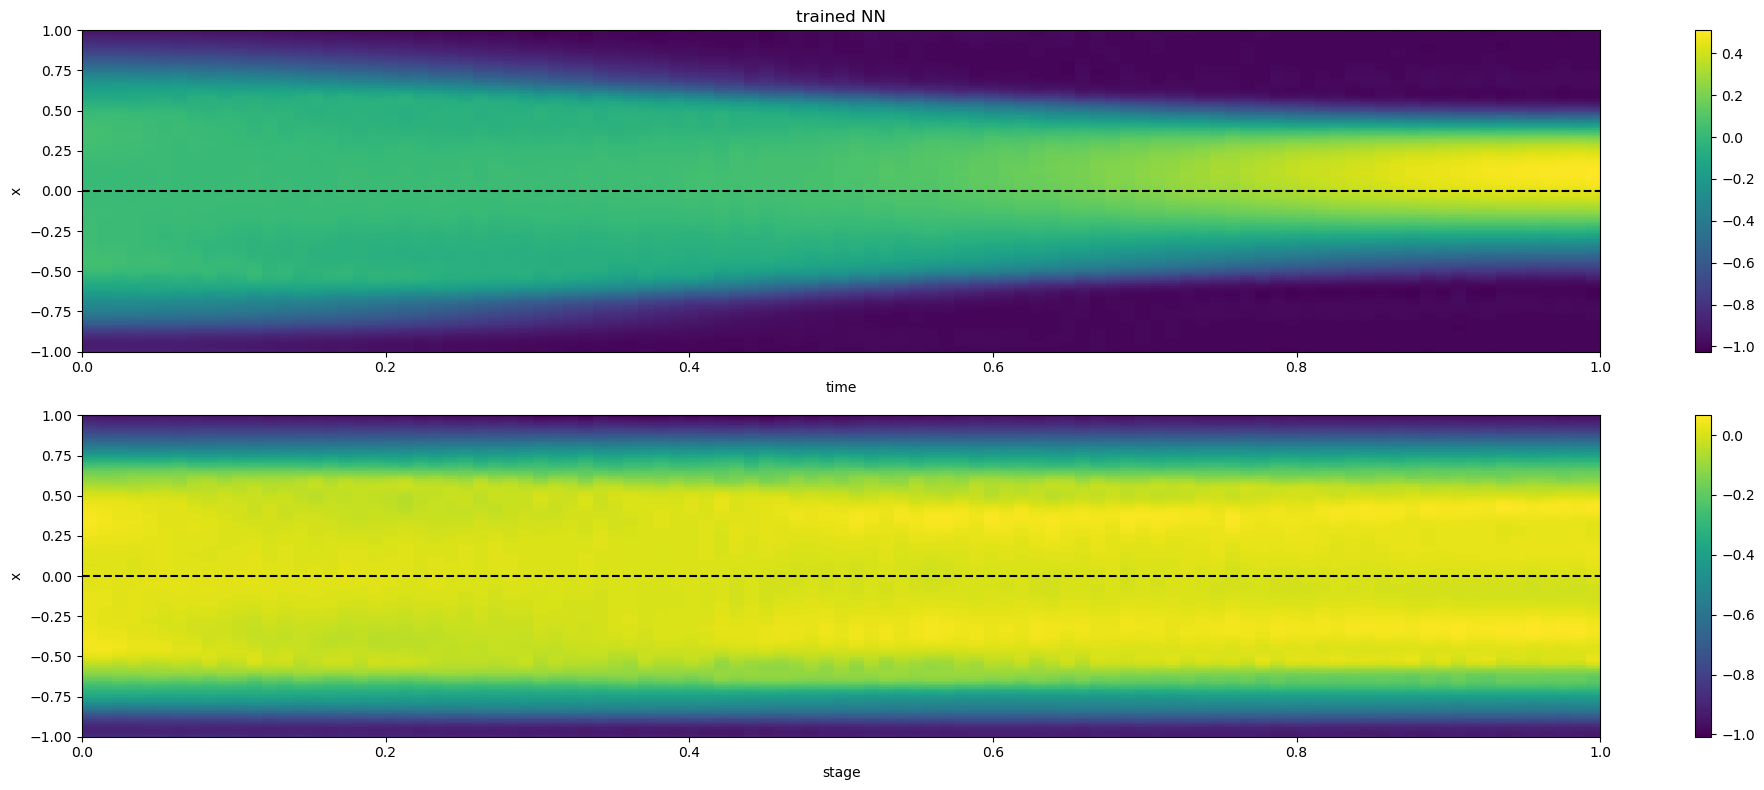

In [28]:
neural_network.show_state("trained NN");

In [29]:
u_n_c = neural_network.u_n_c(neural_network.x)

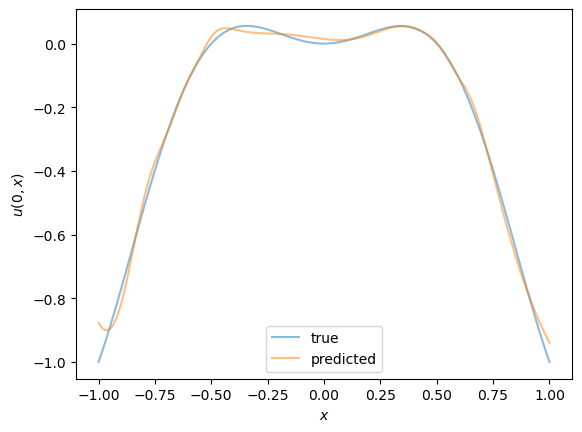

In [30]:
plt.plot(np.linspace(-1, 1, 100), neural_network.u_at_t0(np.linspace(-1, 1, 100)), alpha=0.5, label="true")
plt.plot(neural_network.x, u_n_c[:,0], alpha=0.5, label="predicted")
plt.xlabel('$x$')
plt.ylabel('$u(0,x)$')
plt.legend();

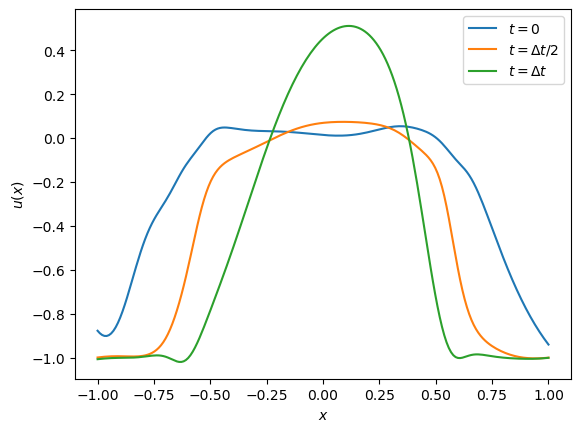

In [31]:
plt.plot(neural_network.x, u_n_c[:,0], label=r"$t = 0$")
plt.plot(neural_network.x, u_n_c[:,u_n_c.shape[1]//2], label=r"$t = \Delta t/2$")
plt.plot(neural_network.x, u_n_c[:,-1], label=r"$t = \Delta t$")
plt.xlabel('$x$')
plt.ylabel('$u(x)$')
plt.legend();

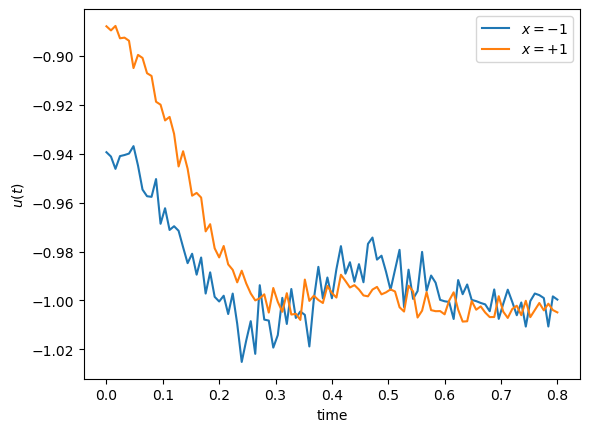

In [32]:
plt.plot(np.linspace(0, neural_network.dt, u_n_c.shape[1]), u_n_c[-1], label="$x = -1$")
plt.plot(np.linspace(0, neural_network.dt, u_n_c.shape[1]), u_n_c[1], label="$x = +1$")
plt.xlabel('time')
plt.ylabel('$u(t)$')
plt.legend();